**Proje Konusu: YSA’ların sınırları**

25*25’lik binary bir matris girişine karşılık aşağıdaki çıktıları üreten 5 YSA eğitiniz.

- A) Matriste 5 nokta (rasgele konumlarda) bulunmaktadır. Model bu noktalardan birbirine en yakın olan ikisi arasındaki Manhattan mesafesini çıktı olarak verecektir. 
- B) A’nin aynısı sadece en yakın yerine en uzak olan ikisi… 
- C) Matriste değişken sayıda (her girişte farklı sayıda olabilir) N adet (1 10 arası) nokta (rasgele konumlarda) bulunmaktadır. Model nokta sayısını çıktı olarak verecektir. 
- D) C’nin aynısı ama çıkış, nokta sayısının tek mi çift mi olduğu 
- E) C’nin aynısı ama çıkış, nokta sayısı tek ise sol üst köşeye en yakın olan noktanın sol üst köşeye Manhattan mesafesi, çift ise sağ alt köşeye en yakın olan noktanın sağ alt köşeye Manhattan mesafesi

YSA modeli olarak RNN, MLP, CNN, Transformer vb. istediğinizi kullanabilirsiniz.<br> 
Her problemde farklı birini de aynılarını da kullanabilirsiniz.

- 5 problemin her biri için: En az 800 örneğe sahip eğitim, 200 örneğe sahip test kümesi oluşturunuz.
- Her eğitim ve test kümesinde çıkışların dağılımı eşit olmalıdır. Örneğin A’da aradaki mesafeler 1-50 aralığında değişiyorsa her aralıktan eşit sayıda örnek olmalıdır. Kümeler buna göre oluşturulmalıdır.
- YSA ların hiperparametre optimizasyonunu nasıl yaptığınızı raporlayınız.
- Eğitim kümesinin çeyrek, yarım ve tam halleri için eğitim yapıp test kümesi üzerindeki performansını raporlayınız.
- Yanlış ve doğru yapılan test örneklerini kendi gözünüzle inceleyip, modellerin neyi öğrenebildiğini / öğrenemediğini yorumlayınız.
- Bulgularınızı tablolar ve grafiklerle sunun, yorumlayın.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from collections import Counter
from util import load_dataset, plot_mat

In [2]:
GRID_SIZE = 25
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu")

x_train, y_train, x_test, y_test = load_dataset('B')

[+] Problem B veri seti başarıyla yüklendi.
    Train -> X: (1128, 25, 25), y: (1128,)
    Test  -> X: (282, 25, 25), y: (282,)


In [3]:
class ProblemBCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Nesneler (x, y) koordinatlarından oluşuyor.
        # Çiftler ise (x_i, y_i, x_j, y_j) şeklinde 4 boyutlu olacak.
        self.g_theta = nn.Sequential(
            nn.Linear(4, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU()
        )
        
        # Toplam vektör 32 boyutlu çıkacak, f_phi onu alıp tek sayıya (mesafe) düşürecek
        self.f_phi = nn.Sequential(
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )
        
    def forward(self, x):
        """
        x: (Batch, 25, 25)
        """
        b = x.size(0)
        
        # noktaların koordinatlarını bulma (5, 2)
        objects = torch.nonzero(x == 1).float()[:, 1:].view(b, 5, 2).to(x.device)
        objects = objects / 24.0
        
        # ikili kombinasyonları oluşturma
        o_i = objects.unsqueeze(2).expand(b, 5, 5, 2) # (Batch, 5, 5, 2)
        o_j = objects.unsqueeze(1).expand(b, 5, 5, 2) # (Batch, 5, 5, 2)
        
        # çiftleri birleştir (Batch, 5, 5, 4) -> [x_i, y_i, x_j, y_j]
        pairs = torch.cat([o_i, o_j], dim=-1)
        
        # g_theta ile ilişkileri öğren (Artık sadece 25 çift üzerinden geçiyor!)
        g_out = self.g_theta(pairs) # (Batch, 5, 5, 32)
        
        # min aggregation
        f_in = torch.amax(g_out, dim=(1, 2))
        
        # f_phi ile sonucu üret
        out = self.f_phi(f_in) # (Batch, 1)
        
        return out

In [4]:
torch.manual_seed(11337)

x_train_tensor = torch.tensor(x_train).float()
y_train_tensor = torch.tensor(y_train).float()
x_test_tensor = torch.tensor(x_test).float()
y_test_tensor = torch.tensor(y_test).float()

# 2. Artık Tensör oldukları için TensorDataset sorunsuz çalışacaktır
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
test_dataset = TensorDataset(x_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1024, shuffle=False)

# 2. Model, Loss ve Optimizatör
model = ProblemBCNN().to(device)
model.train()

criterion = nn.MSELoss() 
optimizer = optim.AdamW(model.parameters())

epochs = 10000

In [5]:
for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device).float().view(-1, 1)

        optimizer.zero_grad()
        predictions = model(batch_x)

        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    model.eval()
    test_mae = 0.0
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device).float().view(-1, 1)
            predictions = model(batch_x)
            test_mae += torch.mean(torch.abs(predictions - batch_y)).item()
    avg_test_mae = test_mae / len(test_loader)

    if (epoch + 1) % 1000 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.4f} | Test Error: {avg_test_mae:.4f}")

Epoch [1000/10000] | Train Loss: 2.1695 | Test Error: 1.2202
Epoch [2000/10000] | Train Loss: 0.1506 | Test Error: 0.3426
Epoch [3000/10000] | Train Loss: 0.0336 | Test Error: 0.1688
Epoch [4000/10000] | Train Loss: 0.0164 | Test Error: 0.1253
Epoch [5000/10000] | Train Loss: 0.0057 | Test Error: 0.0833
Epoch [6000/10000] | Train Loss: 0.0036 | Test Error: 0.0707
Epoch [7000/10000] | Train Loss: 0.0025 | Test Error: 0.0495
Epoch [8000/10000] | Train Loss: 0.0034 | Test Error: 0.0418
Epoch [9000/10000] | Train Loss: 0.0024 | Test Error: 0.0367
Epoch [10000/10000] | Train Loss: 0.0011 | Test Error: 0.0288


In [6]:
def predict(model, x_data):
    model.eval()
    
    if not isinstance(x_data, torch.Tensor):
        x_data = torch.tensor(x_data, dtype=torch.float32)

    is_single = (x_data.dim() == 2)
    
    if is_single:
        x_data = x_data.unsqueeze(0)
        
    device = next(model.parameters()).device
    x_data = x_data.to(device)

    with torch.no_grad():
        sonuc = model(x_data)
        
    sonuc_tensor = torch.round(sonuc).int()
    
    if is_single:
        return sonuc_tensor.item()
    else:
        return sonuc_tensor.flatten()


Hata Farkı Haritası (Fark: Adet): {1: 1}


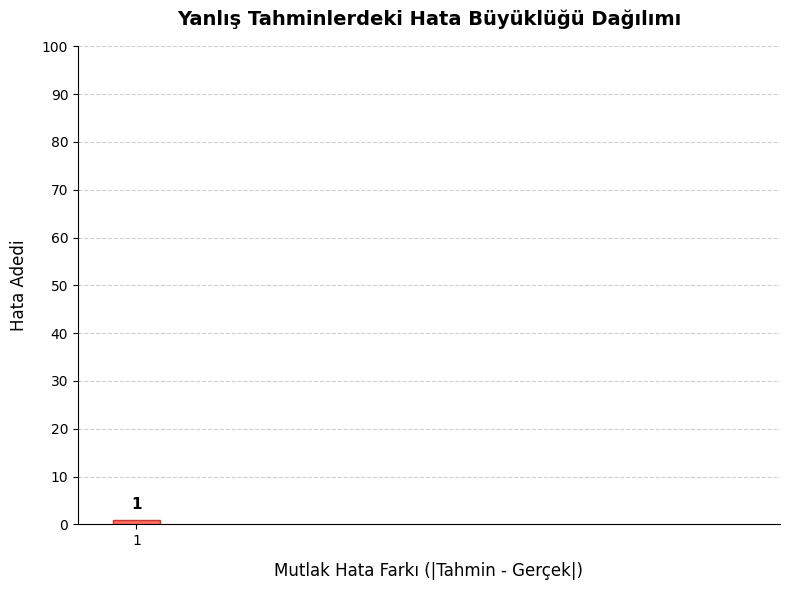

In [7]:
wrong_indices = []
error_diffs = []

with torch.no_grad():
    if not isinstance(x_test, torch.Tensor):
        x_test = torch.tensor(x_test, dtype=torch.float32)
    x_test = x_test.to(device)
    preds = predict(model, x_test)

for i, (pred, y) in enumerate(zip(preds, y_test, strict=True)):
    if pred != y:
        # Hatanın büyüklüğünü (mutlak farkını) hesapla
        diff = abs(int(pred) - int(y)) 
        
        wrong_indices.append((i, y, pred))
        error_diffs.append(diff)

Y_EKSENI_MAKSIMUM = 100 

diff_map = dict(Counter(error_diffs))
print("\nHata Farkı Haritası (Fark: Adet):", diff_map)

if error_diffs:
    sorted_diffs = sorted(diff_map.keys())
    counts = [diff_map[d] for d in sorted_diffs]
    x_labels = [str(d) for d in sorted_diffs]

    fig_width = max(8, len(sorted_diffs) * 0.7)
    fig, ax = plt.subplots(figsize=(fig_width, 6))
    
    bars = ax.bar(x_labels, counts, color='#FF6F61', edgecolor='#CC3333', width=0.4, zorder=3)

    if len(sorted_diffs) < 6:
        ax.set_xlim(-0.5, 5.5)

    max_count = max(counts) if counts else 1
    
    # Her zaman 0'dan başlar. Tavan değeri ise belirlediğiniz limit (100) ile grafikteki en yüksek bar arasında seçilir.
    ax.set_ylim(0, max(Y_EKSENI_MAKSIMUM, max_count + (max_count * 0.1)))

    for bar in bars:
        yval = bar.get_height()
        if yval > 0: 
            # Yazıları yazdırırken üst kısımdaki boşluk (tavan yüksekliğine göre ayarlandı)
            ax.text(bar.get_x() + bar.get_width()/2, yval + (ax.get_ylim()[1] * 0.015), 
                    int(yval), ha='center', va='bottom', fontsize=11, fontweight='bold')

    ax.set_title('Yanlış Tahminlerdeki Hata Büyüklüğü Dağılımı', fontsize=14, pad=15, fontweight='bold')
    ax.set_xlabel('Mutlak Hata Farkı (|Tahmin - Gerçek|)', fontsize=12, labelpad=10)
    ax.set_ylabel('Hata Adedi', fontsize=12, labelpad=10)
    
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    
    ax.grid(axis='y', linestyle='--', alpha=0.6, zorder=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()


--- İlk 5 Hatalı Tahmin Görselleştiriliyor ---

İndeks: 201 | Gerçek Değer: 24 | Tahmin: 23 | Hata Payı: 1


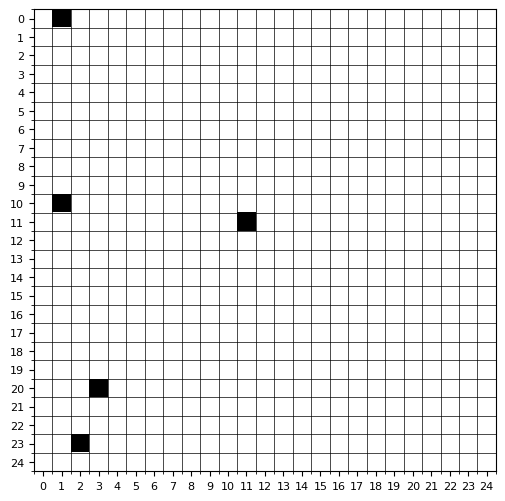

In [8]:
# Gösterilecek maksimum hatalı örnek sayısı
gosterilecek_adet = 5

print(f"\n--- İlk {gosterilecek_adet} Hatalı Tahmin Görselleştiriliyor ---")

for count, (idx, true_y, pred_y) in enumerate(wrong_indices):
    if count >= gosterilecek_adet:
        break # Sınıra ulaşınca döngüyü bitir
        
    fark = abs(int(pred_y) - int(true_y))
    print(f"\nİndeks: {idx} | Gerçek Değer: {true_y} | Tahmin: {pred_y} | Hata Payı: {fark}")
    
    # x_test GPU'da (cuda) olduğu için matplotlib sorun çıkarabilir.
    # plot_mat fonksiyonunuzun beklentisine göre x_test'i CPU'ya alıp numpy'a çeviriyoruz.
    # Eğer plot_mat doğrudan PyTorch tensörlerini destekliyorsa sadece x_test[idx] de yazabilirsiniz.
    matris = x_test[idx].cpu().numpy() if isinstance(x_test[idx], torch.Tensor) else x_test[idx]
    
    plot_mat(matris)